In [29]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

In [23]:
#pip install xgboost

In [31]:
df = pd.read_csv("C:\\Users\\marco\\Desktop\\DM2\\df_postoutliers.csv")


In [33]:
target = "Physical-HeartRate"

# leakage: blocco PCIAT + sii + sedentary_social_withdrawal
leak = [c for c in df.columns if "PCIAT" in c] + ["sii", "sedentary_social_withdrawal"]
num = df.select_dtypes(include=[np.number])
feature_cols = [c for c in num.columns if c not in leak and c != target]
X = num[feature_cols].fillna(num[feature_cols].median())
y = df[target].values
feature_names = np.array(feature_cols)
print(f"y stats -> min: {y.min():.1f}, max: {y.max():.1f}, mean: {y.mean():.1f}, std: {y.std():.1f}")


y stats -> min: 33.0, max: 138.0, mean: 81.9, std: 10.7


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.3, random_state=100)

RANDOM FOREST REGRESSOR
R²:   0.100
RMSE: 10.06
MAE:  7.11


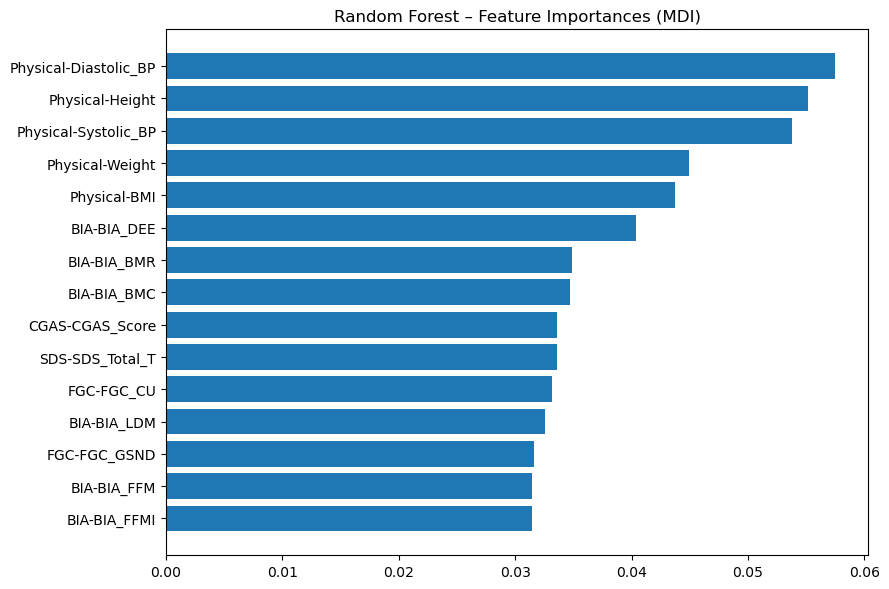

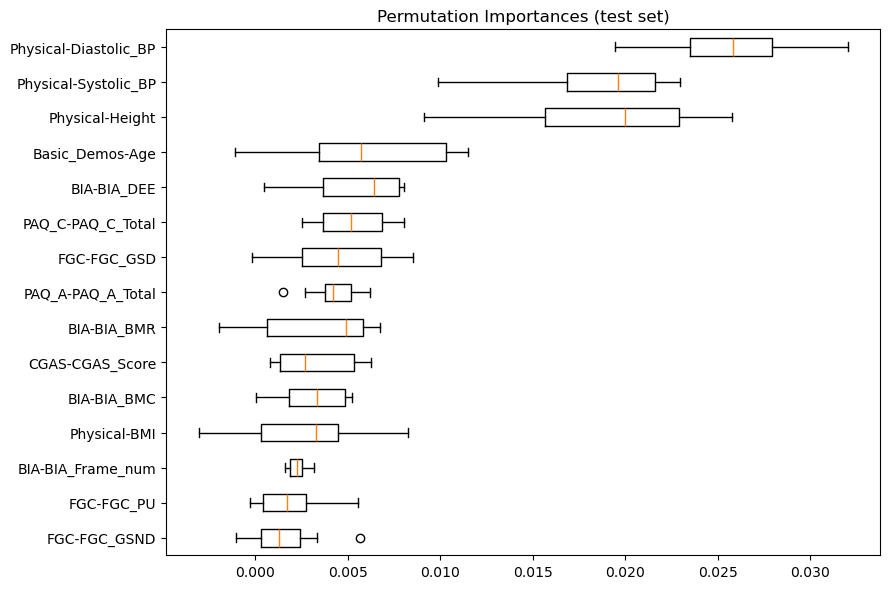

In [37]:
# === Modello 1: Random Forest Regressor ===
rf = RandomForestRegressor(max_features='sqrt', random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RANDOM FOREST REGRESSOR")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")

nbr = 15
idx = rf.feature_importances_.argsort()[-nbr:]
plt.figure(figsize=(9, 6))
plt.barh(np.arange(nbr), rf.feature_importances_[idx])
plt.yticks(np.arange(nbr), feature_names[idx])
plt.title("Random Forest – Feature Importances (MDI)")
plt.tight_layout()
plt.savefig('rf_reg_feature_importance_mdi.png', dpi=300, bbox_inches='tight')
plt.show()

res = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
idx_p = res.importances_mean.argsort()[-nbr:]
plt.figure(figsize=(9, 6))
plt.boxplot(res.importances[idx_p].T, vert=False, labels=feature_names[idx_p])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.savefig('rf_reg_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
# === Modello 2: XGBoost Regressor (con tuning, non i parametri di IMDB) ===
from sklearn.model_selection import RandomizedSearchCV, KFold

param_xgb = {
    'n_estimators':     [100, 200, 400],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_lambda':       [1, 5, 10],
    'reg_alpha':        [0, 1],
    'gamma':            [0, 0.1, 0.3],
}
search = RandomizedSearchCV(
    XGBRegressor(objective='reg:squarederror', tree_method='hist', random_state=42, n_jobs=1),
    param_xgb, n_iter=30, cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1, random_state=42)
search.fit(X_train, y_train)
xgb = search.best_estimator_
y_pred_xgb = xgb.predict(X_test)
print("XGBOOST REGRESSOR (tunato)")
print(f"Best params: {search.best_params_}")
print(f"R²:   {r2_score(y_test, y_pred_xgb):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.2f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.2f}")

XGBOOST REGRESSOR (tunato)
Best params: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 0.8}
R²:   0.117
RMSE: 9.96
MAE:  7.05
